In [1]:
import numpy as np
from collections import Counter

In [2]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [6]:
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    print(distances)
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

In [7]:
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

In [8]:
prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

[(np.float64(4.242640687119285), 'A'), (np.float64(2.8284271247461903), 'A'), (np.float64(1.4142135623730951), 'A'), (np.float64(2.8284271247461903), 'B'), (np.float64(4.242640687119285), 'B')]
A


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# Splitting the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [12]:
K = []
training = []
test = []
scores = {}

for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)

    training_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]



In [13]:
for keys, values in scores.items():
    print(keys, ':', values)

2 : [0.9623115577889447, 0.9005847953216374]
3 : [0.9522613065326633, 0.9181286549707602]
4 : [0.9472361809045227, 0.9298245614035088]
5 : [0.9396984924623115, 0.9473684210526315]
6 : [0.9321608040201005, 0.935672514619883]
7 : [0.9371859296482412, 0.9532163742690059]
8 : [0.9371859296482412, 0.9532163742690059]
9 : [0.9321608040201005, 0.9590643274853801]
10 : [0.9321608040201005, 0.9532163742690059]
11 : [0.9346733668341709, 0.9649122807017544]
12 : [0.9346733668341709, 0.9649122807017544]
13 : [0.9296482412060302, 0.9649122807017544]
14 : [0.9296482412060302, 0.9649122807017544]
15 : [0.9321608040201005, 0.9649122807017544]
16 : [0.9296482412060302, 0.9649122807017544]
17 : [0.9321608040201005, 0.9649122807017544]
18 : [0.9346733668341709, 0.9649122807017544]
19 : [0.9246231155778895, 0.9649122807017544]
20 : [0.9246231155778895, 0.9649122807017544]


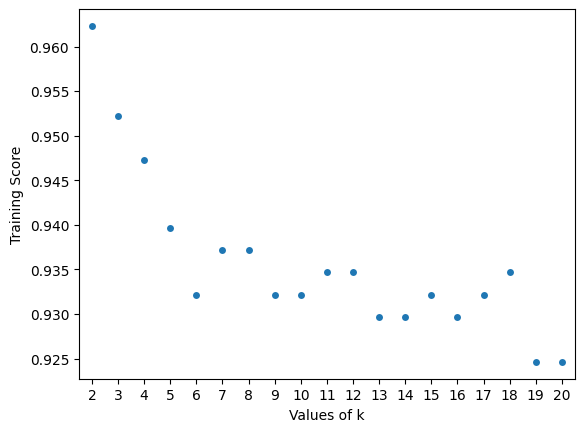

In [14]:
ax = sns.stripplot(x=K, y=training)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Training Score')
plt.show()